# 의료시설 접근성 Isochrone (30분/60분) — 2026-09-01 09:00 오전 첨두

r5py `Isochrones`로, 대상 지역 20km 버퍼 내 의료시설(3,887개)을 origin으로 하는
30분·60분 등시간대(isochrone)를 계산한다. `Isochrones`는 origin을 여러 개 넣으면
**"이들 중 어느 것으로부터든 최소 이동시간" 기준의 통합 등시간대**를 반환하므로,
"가장 가까운 의료시설까지 30분/60분 내 도달 가능한 영역"을 그대로 얻을 수 있다.

## 파라미터

| 항목 | 값 |
|---|---|
| Origin | 의료시설(병원·의원·종합병원·보건소·보건지소·보건의료원·보건진료소), 대상 지역 20km 버퍼 내 (3,887개) |
| Isochrone 임계값 | 30분, 60분 |
| 출발일시 | 2026-09-01(화) 09:00:00 (오전 첨두) |
| departure_time_window | 1시간 |
| transport_modes | TRANSIT, WALK |
| speed_walking | 4.5 km/h |
| max_time_walking | 15분 |
| max_public_transport_rides | 5회 |

무거운 계산(`compute_isochrones.py`, 약 40분 소요)은 별도 스크립트로 실행하며,
이 노트북은 결과(`data/isochrones_20260901_0900/isochrones_final.gpkg`)를 불러와 지도화한다.

**참고**: `Isochrones`는 origin당 약 0.6~1초로 `TravelTimeMatrix`보다 훨씬 무겁다(목적지 수와
무관하게 origin 수가 비용을 지배). 그래서 origin(의료시설 3,887개)을 500개씩 청크로 나눠
처리했다. 반환되는 geometry는 등고선(MULTILINESTRING)이라 `shapely.ops.polygonize`로
닫힌 폴리곤으로 변환한 뒤, 청크 간에는 폴리곤 union으로 합쳤다
(min(A∪B) 도달영역 = min(A) 도달영역 ∪ min(B) 도달영역이 성립하므로 청크 분할이 안전).

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

## 결과 로드

In [2]:
iso = gpd.read_file("data/isochrones_20260901_0900/isochrones_final.gpkg")
print(iso[["minutes"]])
iso["area_km2"] = iso.to_crs("EPSG:5179").geometry.area / 1e6
iso[["minutes", "area_km2"]]

   minutes
0       30
1       60


,minutes,area_km2
0,30,1995.960819
1,60,4153.589474


**참고**: 위 면적은 origin(20km 버퍼 내 의료시설)이 만들어내는 등시간대 전체 범위 기준이라, 버퍼
때문에 대상 10개 시군구 밖(예: 인접 시군구 일부)의 도달 가능 영역도 일부 포함되어 있다.
아래 지도·면적 통계는 대상 시군구 경계로 잘라낸 뒤 계산한다.

## 시각화

60분 isochrone(더 넓은 영역)을 아래에, 30분 isochrone(더 좁은 영역)을 위에 겹쳐 그린다.

대상 시군구 내 면적:
   minutes     area_km2
0       30  1655.433376
1       60  3791.740445


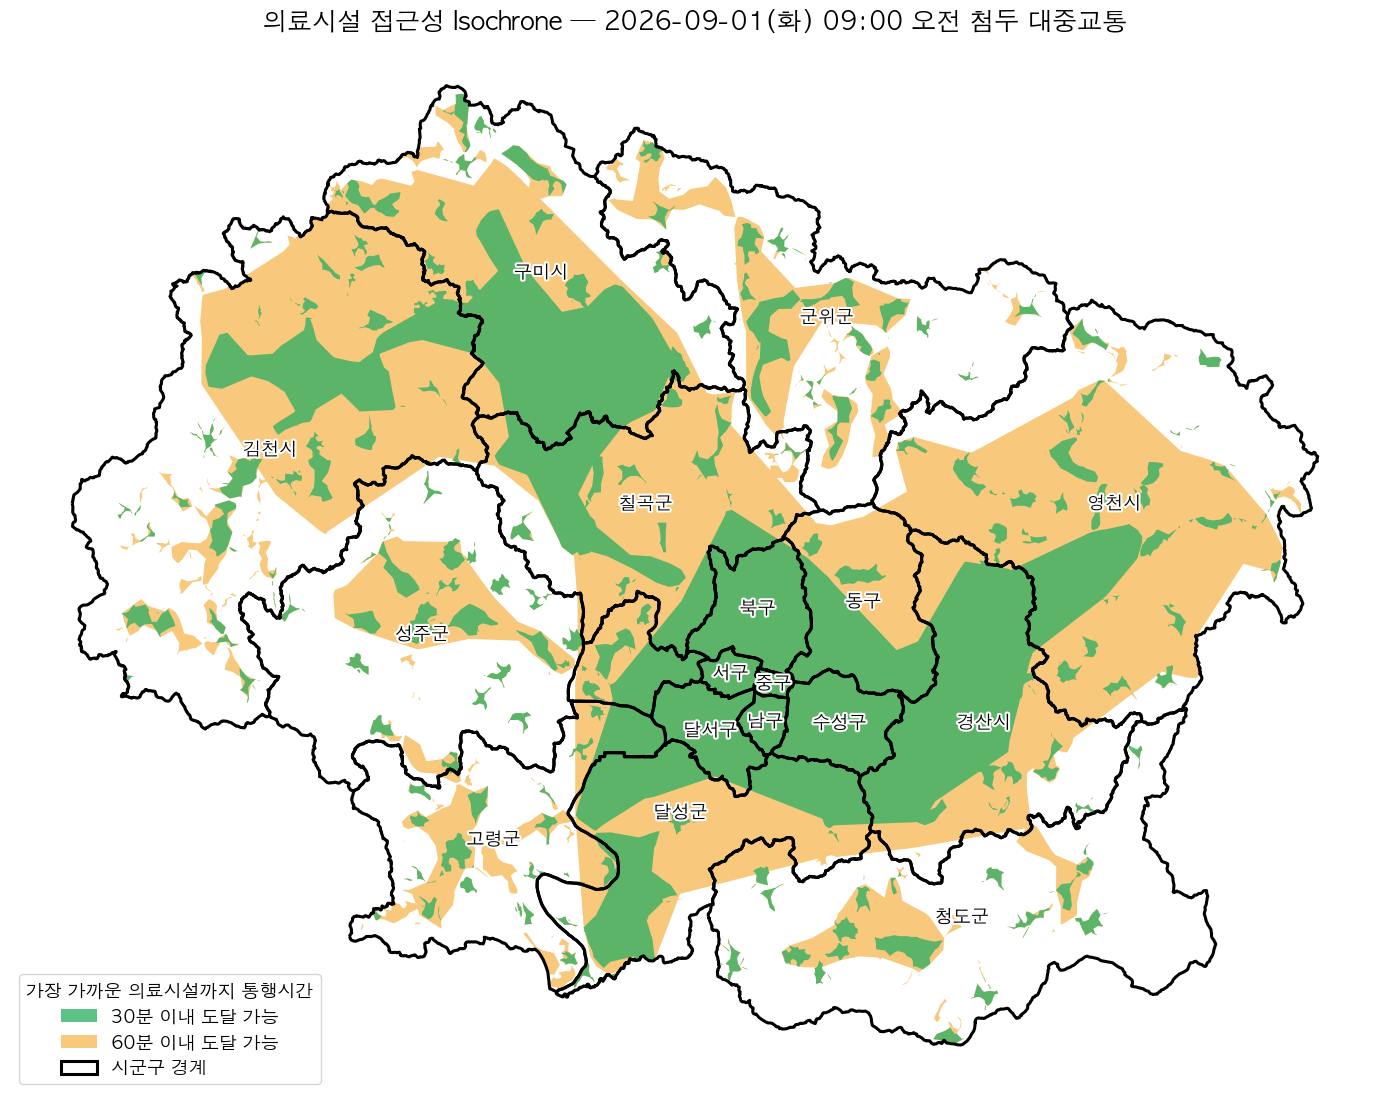

In [3]:
sigungu = gpd.read_file("data/BND_SIGUNGU_PG/BND_SIGUNGU_PG.shp", encoding="cp949")
target_codes = [
    "22010", "22020", "22030", "22040", "22050", "22060", "22070", "22510", "22520",
    "37050", "37030", "37070", "37100", "37560", "37570", "37580", "37590",
]
target_sigungu = sigungu[sigungu["SIGUNGU_CD"].isin(target_codes)].to_crs(iso.crs)
target_union = target_sigungu.union_all()

# 대상 시군구 경계로 자른 뒤 지도화 (원본 계산은 20km 버퍼 내 시설 기준이라 그대로 두면
# 버퍼 지역의 자잘한 조각들이 화면을 어수선하게 만듦)
iso_clipped = iso.copy()
iso_clipped["geometry"] = iso_clipped.geometry.intersection(target_union)
iso_clipped["area_km2"] = iso_clipped.to_crs("EPSG:5179").geometry.area / 1e6
print("대상 시군구 내 면적:")
print(iso_clipped[["minutes", "area_km2"]])

fig, ax = plt.subplots(figsize=(14, 14))

iso60 = iso_clipped[iso_clipped["minutes"] == 60]
iso30 = iso_clipped[iso_clipped["minutes"] == 30]

iso60.plot(ax=ax, color="#f39c12", alpha=0.55, zorder=1, label="60분 이내")
iso30.plot(ax=ax, color="#27ae60", alpha=0.75, zorder=2, label="30분 이내")

target_sigungu.boundary.plot(ax=ax, color="black", linewidth=2.2, zorder=3)
for _, row in target_sigungu.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["SIGUNGU_NM"], xy=(c.x, c.y), ha="center", va="center",
        fontsize=13, fontweight="bold", color="black", zorder=4,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

legend_elements = [
    Patch(facecolor="#27ae60", alpha=0.75, label="30분 이내 도달 가능"),
    Patch(facecolor="#f39c12", alpha=0.55, label="60분 이내 도달 가능"),
    Patch(facecolor="none", edgecolor="black", linewidth=2.2, label="시군구 경계"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=13,
          title="가장 가까운 의료시설까지 통행시간", title_fontsize=13)

ax.set_title("의료시설 접근성 Isochrone — 2026-09-01(화) 09:00 오전 첨두 대중교통", fontsize=18, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("data/isochrones_20260901_0900/isochrone_map_20260901_0900.png", dpi=200)
plt.show()